[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/05_mobilenet_v3.ipynb)

# MobileNet V3

**CSC3109 - Machine Learning | Team 16 — Jocasta**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")
print("Policy : 70/30 split inside each class folder in data/set 16")

ROOT   : /content/CSC3109-T16-Project
Device : cpu
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val
Policy : 70/30 split inside each class folder in data/set 16


## 1. Data Loading
 The dataloader applies the shared project split: a 70/30 split inside each class folder in `data/set 16`. This keeps every class at 490 train and 210 validation images.

In [3]:
from src.dataset import get_dataloaders

train_loader, val_loader, classes = get_dataloaders(
    root        = ROOT,
    data_dir    = DATA_DIR,
    batch_size  = BATCH_SIZE,
    image_size  = IMAGE_SIZE,
    train_ratio = TRAIN_RATIO,
    seed        = SEED,
    num_workers = 2,
)

def subset_class_counts(subset, class_names):
    targets = subset.dataset.targets
    counts = {cls: 0 for cls in class_names}
    for idx in subset.indices:
        counts[class_names[targets[idx]]] += 1
    return counts

print(f"Classes       : {classes}")
print(f"Split policy  : {TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%} inside each class folder")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} images)")
print(f"Train counts  : {subset_class_counts(train_loader.dataset, classes)}")
print(f"Val counts    : {subset_class_counts(val_loader.dataset, classes)}")

Classes       : ['beach', 'ferry_terminal', 'harbor', 'river']
Split policy  : 70%/30% inside each class folder
Train batches : 62  (1960 images)
Val batches   : 27  (840 images)
Train counts  : {'beach': 490, 'ferry_terminal': 490, 'harbor': 490, 'river': 490}
Val counts    : {'beach': 210, 'ferry_terminal': 210, 'harbor': 210, 'river': 210}


## 2. Model Setup
MobileNetV3-Small was selected as a lightweight transfer-learning baseline, well suited to fast inference and deployment. ImageNet pretrained weights were used, and the final classification layer was replaced to output the four scene classes. During Phase 1, the backbone was kept frozen so that only the new classifier was trained before fine-tuning the entire model in Phase 2.

In [4]:
from src.models import get_mobilenet_v3
from src.utils import count_parameters

model = get_mobilenet_v3(num_classes=NUM_CLASSES, pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model = model.to(DEVICE)

total_params = count_parameters(model)
print(f"Trainable parameters (Phase 1 - head only) : {total_params / 1e6:.4f} M")
print(f"Model head                                  : {model.classifier}")
print(f"Running on                                  : {DEVICE}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 71.4MB/s]

Trainable parameters (Phase 1 - head only) : 0.5949 M
Model head                                  : Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=4, bias=True)
)
Running on                                  : cpu


## 3. Training the model
MobileNetV3-Small was trained in 2 phases.

Phase 1: Only the new classification head was trained while the pretrained backbone remained frozen. This allows the new classifier to learn first without changing the pretrained features too quickly.

Phase 2: The backbone was unfrozen and the whole model was fine-tuned using a lower learning rate together with CosineAnnealingLR. This helps the pretrained features adapt gradually to the dataset.

Since `train()` resets the best validation accuracy each time it is called, each phase saves its own checkpoint. After training, the checkpoint with the higher validation accuracy is selected as the final model.

### 3a. Phase 1: Frozen backbone

In [5]:
import torch
from src.train import train

SAVE_PATH_P1 = ROOT / "results" / "saved_models" / "mobilenet_v3_phase1.pth"
PHASE1_EPOCHS = 8

optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
)

history_p1 = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_p1,
    scheduler=None,
    num_epochs=PHASE1_EPOCHS,
    device=DEVICE,
    save_path=SAVE_PATH_P1,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/8]  train loss: 0.2536  train acc: 0.9163  val loss: 0.0618  val acc: 0.9833  (38.8s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/mobilenet_v3_phase1.pth  (val_acc=0.9833)
Epoch [02/8]  train loss: 0.1653  train acc: 0.9327  val loss: 0.0496  val acc: 0.9833  (34.2s)
Epoch [03/8]  train loss: 0.1111  train acc: 0.9622  val loss: 0.1829  val acc: 0.9369  (34.5s)
Epoch [04/8]  train loss: 0.1072  train acc: 0.9617  val loss: 0.0871  val acc: 0.9655  (35.3s)
Epoch [05/8]  train loss: 0.0990  train acc: 0.9638  val loss: 0.0718  val acc: 0.9643  (34.1s)
Epoch [06/8]  train loss: 0.1087  train acc: 0.9602  val loss: 0.0375  val acc: 0.9821  (34.4s)
Epoch [07/8]  train loss: 0.0832  train acc: 0.9689  val loss: 0.0476  val acc: 0.9810  (34.8s)
Epoch [08/8]  train loss: 0.0874  train acc: 0.9699  val loss: 0.0404  val acc: 0.9833  (35.4s)

Training complete. Best val acc: 0.9833


### 3b. Phase 2: Unfreeze and fine-tune

In [6]:
SAVE_PATH_P2 = ROOT / "results" / "saved_models" / "mobilenet_v3_phase2.pth"
PHASE2_EPOCHS = 12

for param in model.features.parameters():
    param.requires_grad = True

print(f"Trainable parameters (Phase 2 -- full network) : {count_parameters(model) / 1e6:.4f} M")

optimizer_p2 = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS)

history_p2 = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_p2,
    scheduler=scheduler_p2,
    num_epochs=PHASE2_EPOCHS,
    device=DEVICE,
    save_path=SAVE_PATH_P2,
)

Trainable parameters (Phase 2 -- full network) : 1.5220 M
Epoch [01/12]  train loss: 0.0729  train acc: 0.9755  val loss: 0.0273  val acc: 0.9881  (87.8s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/mobilenet_v3_phase2.pth  (val_acc=0.9881)
Epoch [02/12]  train loss: 0.0458  train acc: 0.9816  val loss: 0.0188  val acc: 0.9952  (84.8s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/mobilenet_v3_phase2.pth  (val_acc=0.9952)
Epoch [03/12]  train loss: 0.0283  train acc: 0.9893  val loss: 0.0162  val acc: 0.9964  (85.7s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/mobilenet_v3_phase2.pth  (val_acc=0.9964)
Epoch [04/12]  train loss: 0.0379  train acc: 0.9878  val loss: 0.0225  val acc: 0.9917  (85.8s)
Epoch [05/12]  train loss: 0.0344  train acc: 0.9862  val loss: 0.0154  val acc: 0.9917  (84.3s)
Epoch [06/12]  train loss: 0.0311  train acc: 0.9893  val loss: 0.0137  val acc: 0.9952  (86.0s)
Epoch [07

### 3c. Select best checkpoint

In [7]:
import shutil

SAVE_PATH = ROOT / "results" / "saved_models" / "mobilenet_v3.pth"
best_p1 = max(history_p1["val_acc"])
best_p2 = max(history_p2["val_acc"])

if best_p2 >= best_p1:
    shutil.copy(SAVE_PATH_P2, SAVE_PATH)
    print(f"Using Phase 2 checkpoint (val_acc={best_p2:.4f})")
else:
    shutil.copy(SAVE_PATH_P1, SAVE_PATH)
    print(f"Using Phase 1 checkpoint (val_acc={best_p1:.4f}): Fine-tuning did not help")

print("Training done.")
print("Best model saved to:", SAVE_PATH)

Using Phase 2 checkpoint (val_acc=0.9964)
Training done.
Best model saved to: /content/CSC3109-T16-Project/results/saved_models/mobilenet_v3.pth


## 4. Training Curves
Loss and accuracy plotted over epochs for both train and val splits, combining Phase 1 and Phase 2 into one continuous curve. The visible change at the phase boundary (epoch 8→9) is the empirical evidence for the two-phase choice.

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/mobilenet_v3_training_curve.png


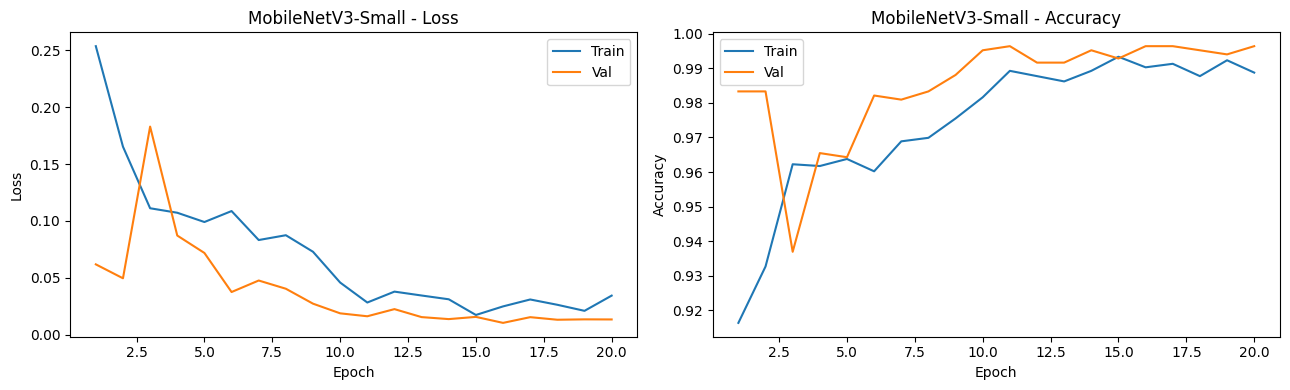

In [8]:
from src.utils import plot_training_curves

history = {key: history_p1[key] + history_p2[key] for key in history_p1}

CURVES_PATH = ROOT / "results" / "training_curves" / "mobilenet_v3_training_curve.png"

plot_training_curves(history, title="MobileNetV3-Small", save_path=CURVES_PATH)

## 5. Evaluation
Loads the best checkpoint saved during training and runs inference on the full val set to get the final accuracy, precision, recall, and F1 score.

In [9]:
import torch
from src.evaluate import get_predictions, compute_metrics, print_report

# Load best saved weights before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

y_pred, y_true = get_predictions(model, val_loader, DEVICE)
metrics        = compute_metrics(y_true, y_pred)

print("=" * 40)
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print("=" * 40)
print()
print_report(y_true, y_pred, CLASS_NAMES)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Accuracy  : 0.9964
  Precision : 0.9964
  Recall    : 0.9964
  F1 Score  : 0.9964

                precision    recall  f1-score   support

         beach       1.00      1.00      1.00       210
ferry_terminal       1.00      0.99      0.99       210
        harbor       0.99      1.00      0.99       210
         river       1.00      1.00      1.00       210

      accuracy                           1.00       840
     macro avg       1.00      1.00      1.00       840
  weighted avg       1.00      1.00      1.00       840



## 6. Confusion Matrix
Shows which classes the model confuses most often. Off-diagonal entries highlight where misclassifications are concentrated

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/mobilenet_v3_confusion_matrix.png


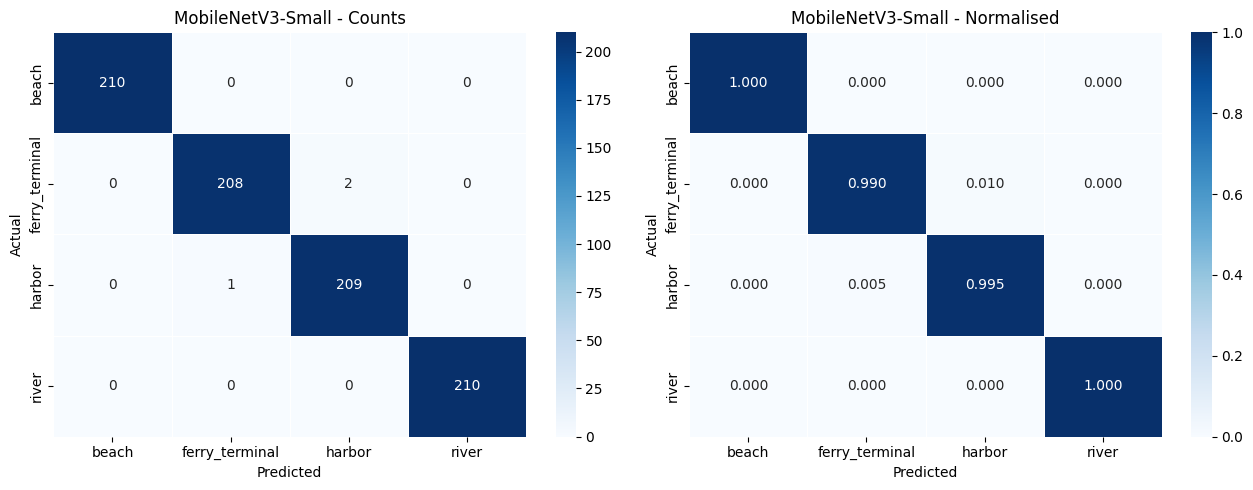

In [10]:
from src.evaluate import plot_confusion_matrix

CM_PATH = ROOT / "results" / "confusion_matrices" / "mobilenet_v3_confusion_matrix.png"

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="MobileNetV3-Small", save_path=CM_PATH)

## 7. Save Metrics
 Writes this model's results to the shared `results/metrics.csv`

In [11]:
from src.utils import save_metrics_to_csv

METRICS_PATH = ROOT / "results" / "metrics.csv"

save_metrics_to_csv("mobilenet_v3", metrics, METRICS_PATH)
print("Results written to results/metrics.csv")

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Results written to results/metrics.csv


## 8. Sample Predictions
Randomly samples two images per class from the val set and runs them through the model. Green titles are correct predictions, red are misclassifications.

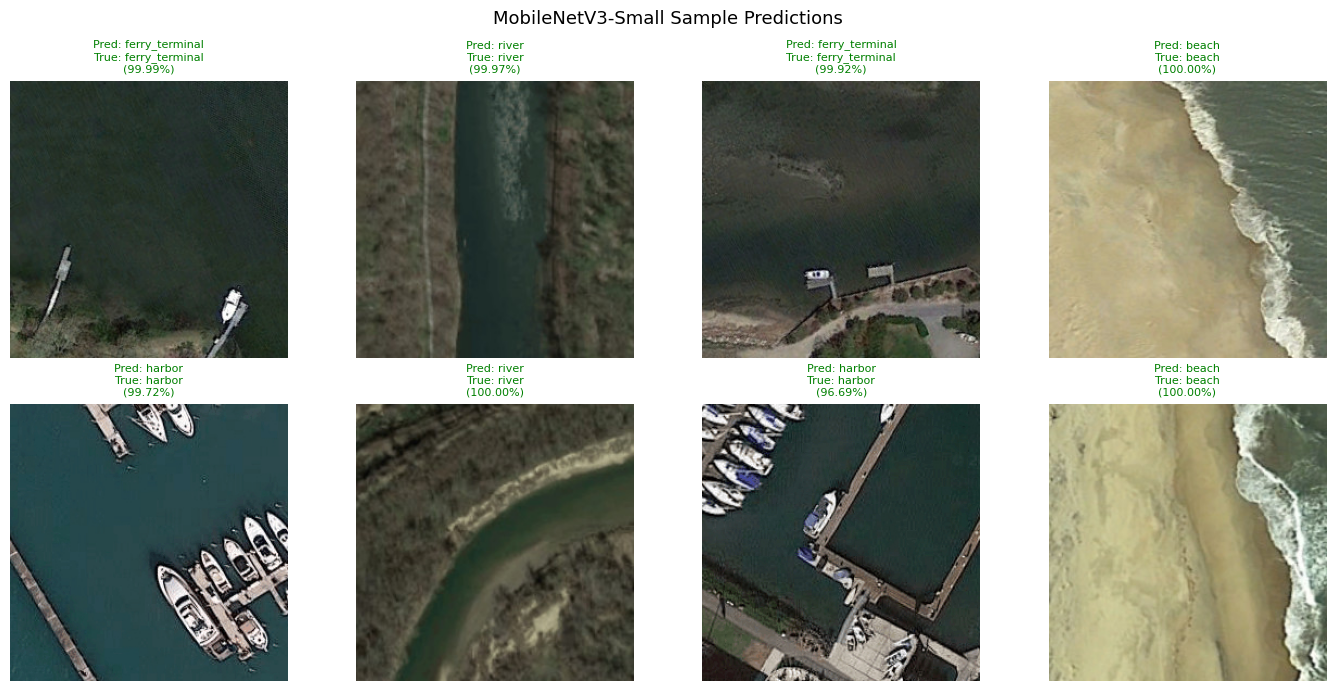

In [12]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from src.predict import predict_image

val_subset = val_loader.dataset
val_paths_by_class = {cls: [] for cls in classes}
for idx in val_subset.indices:
    path, target = val_subset.dataset.samples[idx]
    val_paths_by_class[classes[target]].append(Path(path))

sample_paths = []
for cls in classes:
    imgs = val_paths_by_class[cls]
    sample_paths.extend(random.sample(imgs, min(2, len(imgs))))

random.shuffle(sample_paths)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("MobileNetV3-Small Sample Predictions", fontsize=13)

for ax, path in zip(axes.flat, sample_paths[:8]):
    label, conf, _ = predict_image(path, model, classes, DEVICE, IMAGE_SIZE)
    true_cls = path.parent.name
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if label == true_cls else "red"
    title = f"Pred: {label}\nTrue: {true_cls}\n({conf:.2%})"
    ax.set_title(title, fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 9. Qualitative Error Analysis
A sample of misclassified validation images, to inspect whether errors cluster around visually similar classes.

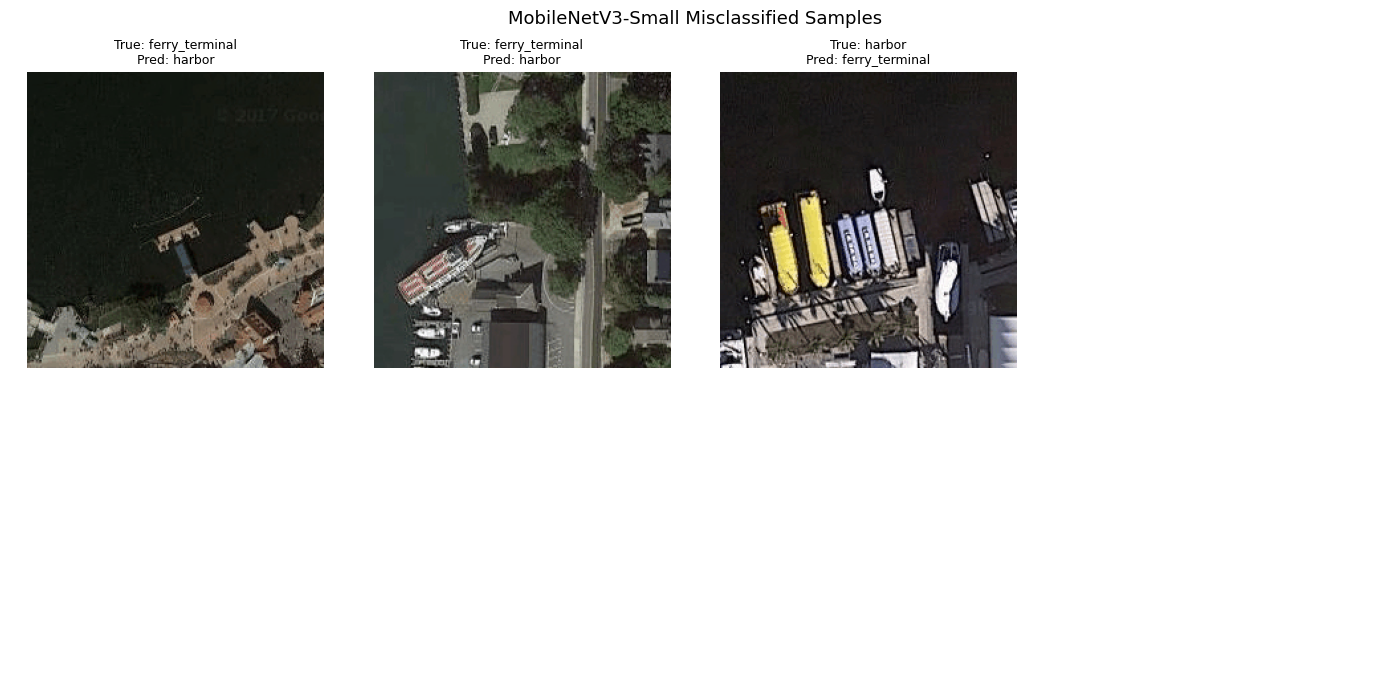

In [13]:
import numpy as np

wrong_idx = np.where(y_pred != y_true)[0]
n_show = min(8, len(wrong_idx))
sample_idx = np.random.RandomState(SEED).choice(wrong_idx, size=n_show, replace=False)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("MobileNetV3-Small Misclassified Samples", fontsize=13)

for ax, idx in zip(axes.flat, sample_idx):
    img, label = val_loader.dataset[idx]
    img = img.permute(1, 2, 0).numpy() * std + mean
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"True: {classes[y_true[idx]]}\nPred: {classes[y_pred[idx]]}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[len(sample_idx):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(ROOT / "results" / "confusion_matrices" / "mobilenet_v3_misclassified.png", bbox_inches="tight")
plt.show()